In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn


C:\Users\User\AppData\Local\Temp\ipykernel_18292\1231621129.py:1: DtypeWarning: Columns (13,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  datas=pd.read_csv('TrainAndValid.csv',parse_dates=['saledate'])


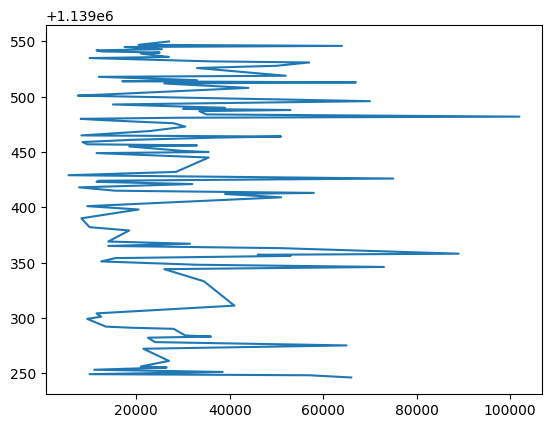

In [3]:
datas=pd.read_csv('TrainAndValid.csv',parse_dates=['saledate'])
datas.head()
datas.T.head()
plt.plot(datas['SalePrice'][0:100],datas['SalesID'][0:100])

In [4]:
datas.saledate[:100]

0    2006-11-16
1    2004-03-26
2    2004-02-26
3    2011-05-19
4    2009-07-23
        ...    
95   2005-12-15
96   2004-01-29
97   2008-09-18
98   2005-11-03
99   2006-06-01
Name: saledate, Length: 100, dtype: datetime64[ns]

In [5]:
# Convert 'saledate' to datetime
# Convert 'saledate' to datetime
df=datas.copy()
df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce')

# Check the datatype to confirm it's now datetime
print(df['saledate'].dtype)

# After conversion, you can safely use the .dt accessor
df['salemonth'] = df['saledate'].dt.month
df['saledayofweek'] = df['saledate'].dt.dayofweek


datetime64[ns]


In [6]:
df.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,salemonth,saledayofweek
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,2006-11-16,...,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional,11,3
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,2004-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional,3,4
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2004-02-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,2011-05-19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,3
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,2009-07-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,3


In [7]:
df.drop('saledate',axis=1)
df.T

,0,1,2,3,4,5,6,7,8,9,...,412688,412689,412690,412691,412692,412693,412694,412695,412696,412697
SalesID,1139246,1139248,1139249,1139251,1139253,1139255,1139256,1139261,1139272,1139275,...,6333305,6333314,6333330,6333339,6333343,6333344,6333345,6333347,6333348,6333349
SalePrice,66000.0,57000.0,10000.0,38500.0,11000.0,26500.0,21000.0,27000.0,21500.0,65000.0,...,11500.0,13000.0,20500.0,13000.0,10000.0,10000.0,10500.0,12500.0,10000.0,13000.0
MachineID,999089,117657,434808,1026470,1057373,1001274,772701,902002,1036251,1016474,...,1800259,1908162,1879923,1856845,1799614,1919201,1882122,1944213,1794518,1944743
ModelID,3157,77,7009,332,17311,4605,1937,3539,36003,3883,...,21437,21437,21446,21435,21435,21435,21436,21435,21435,21436
datasource,121,121,121,121,121,121,121,121,121,121,...,149,149,149,149,149,149,149,149,149,149
auctioneerID,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0
YearMade,2004,1996,2001,2001,2007,2004,1993,2001,2008,1000,...,2006,2006,2006,2005,2005,2005,2005,2005,2006,2006
MachineHoursCurrentMeter,68.0,4640.0,2838.0,3486.0,722.0,508.0,11540.0,4883.0,302.0,20700.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UsageBand,Low,Low,High,High,Medium,Low,High,High,Low,Medium,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
saledate,2006-11-16 00:00:00,2004-03-26 00:00:00,2004-02-26 00:00:00,2011-05-19 00:00:00,2009-07-23 00:00:00,2008-12-18 00:00:00,2004-08-26 00:00:00,2005-11-17 00:00:00,2009-08-27 00:00:00,2007-08-09 00:00:00,...,2012-02-13 00:00:00,2012-01-28 00:00:00,2012-01-28 00:00:00,2012-01-28 00:00:00,2012-02-13 00:00:00,2012-03-07 00:00:00,2012-01-28 00:00:00,2012-01-28 00:00:00,2012-03-07 00:00:00,2012-01-28 00:00:00


In [8]:
df.state.value_counts

<bound method IndexOpsMixin.value_counts of 0                Alabama
1         North Carolina
2               New York
3                  Texas
4               New York
               ...      
412693             Texas
412694           Florida
412695           Florida
412696             Texas
412697           Florida
Name: state, Length: 412698, dtype: object>

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 55 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SalesID                   412698 non-null  int64         
 1   SalePrice                 412698 non-null  float64       
 2   MachineID                 412698 non-null  int64         
 3   ModelID                   412698 non-null  int64         
 4   datasource                412698 non-null  int64         
 5   auctioneerID              392562 non-null  float64       
 6   YearMade                  412698 non-null  int64         
 7   MachineHoursCurrentMeter  147504 non-null  float64       
 8   UsageBand                 73670 non-null   object        
 9   saledate                  412698 non-null  datetime64[ns]
 10  fiModelDesc               412698 non-null  object        
 11  fiBaseModel               412698 non-null  object        
 12  fi

In [ ]:
for label, content in df.items():
    if pd.api.types.is_string_dtype(content):  
        df[label] = content.astype('category').cat.as_ordered()  


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 55 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SalesID                   412698 non-null  int64         
 1   SalePrice                 412698 non-null  float64       
 2   MachineID                 412698 non-null  int64         
 3   ModelID                   412698 non-null  int64         
 4   datasource                412698 non-null  int64         
 5   auctioneerID              392562 non-null  float64       
 6   YearMade                  412698 non-null  int64         
 7   MachineHoursCurrentMeter  147504 non-null  float64       
 8   UsageBand                 73670 non-null   object        
 9   saledate                  412698 non-null  datetime64[ns]
 10  fiModelDesc               412698 non-null  category      
 11  fiBaseModel               412698 non-null  category      
 12  fi

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 55 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SalesID                   412698 non-null  int64         
 1   SalePrice                 412698 non-null  float64       
 2   MachineID                 412698 non-null  int64         
 3   ModelID                   412698 non-null  int64         
 4   datasource                412698 non-null  int64         
 5   auctioneerID              392562 non-null  float64       
 6   YearMade                  412698 non-null  int64         
 7   MachineHoursCurrentMeter  147504 non-null  float64       
 8   UsageBand                 73670 non-null   object        
 9   saledate                  412698 non-null  datetime64[ns]
 10  fiModelDesc               412698 non-null  category      
 11  fiBaseModel               412698 non-null  category      
 12  fi

In [13]:
df.isna()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,salemonth,saledayofweek
0,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
4,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412693,False,False,False,False,False,False,False,True,True,False,...,False,False,False,True,True,True,True,True,False,False
412694,False,False,False,False,False,False,False,True,True,False,...,False,False,False,True,True,True,True,True,False,False
412695,False,False,False,False,False,False,False,True,True,False,...,False,False,False,True,True,True,True,True,False,False
412696,False,False,False,False,False,False,False,True,True,False,...,False,False,False,True,True,True,True,True,False,False


In [14]:
for  label,content in df.items():
  if pd.api.types.is_numeric_dtype(content):
    if pd.isnull(content).sum():
      df[label+'_is_misiing']=pd.isnull(content)
      median_value=content.median()
      df[label]=content.fillna(median_value)


In [15]:
for label,content in df.items():
  if not pd.api.types.is_numeric_dtype(content):
    df[label+'_is_missing']=pd.isnull(content)
    df[label]=pd.Categorical(content).codes+1
    

In [16]:
df.head()
df.isna().sum()

SalesID                         0
SalePrice                       0
MachineID                       0
ModelID                         0
datasource                      0
                               ..
Backhoe_Mounting_is_missing     0
Blade_Type_is_missing           0
Travel_Controls_is_missing      0
Differential_Type_is_missing    0
Steering_Controls_is_missing    0
Length: 102, dtype: int64

In [17]:
%%time
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(n_jobs=-1,random_state=42,max_samples=100)
x_train=df.drop('SalePrice',axis=1)
y_train=df['SalePrice']
model.fit(x_train,y_train)
model.score(x_train,y_train)

CPU times: total: 7.92 s
Wall time: 2.19 s


0.5095150220687134

In [18]:
from sklearn.metrics import mean_absolute_error,mean_squared_log_error,r2_score
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(n_jobs=-1,random_state=42,max_samples=1000)

In [19]:
train_data = df[df['saledate'] != 2012]  # Filter rows where 'saledate' is not 2012
valid_data = df[df['saledate'] == 2012]  # Filter rows where 'saledate' is 2012

# Ensure train_data and valid_data are DataFrames, not Series
x_train, y_train = train_data.drop('SalePrice', axis=1), train_data['SalePrice']
x_valid, y_valid = valid_data.drop('SalePrice', axis=1), valid_data['SalePrice']

In [20]:
def rmsle(y_test,y_predicts):
  return np.sqrt(mean_squared_log_error(y_test,y_predicts))
def scores(model):
  train_predicts=model.predict(x_train)
  valid_predicts=model.predict(x_valid)
  score={'root mean square',rmsle(y_train,train_predicts),
         'r_2 square',r2_score(y_train,train_predicts),
         'rmsle_valid',rmsle(y_valid,valid_predicts),
         'r2_valid',r2_score(y_valid,valid_predicts)

  }
  return score


In [21]:
model.fit(x_train,y_train)
scores(model)

{0.33515329070286604,
 0.36258833116059985,
 0.744173341767254,
 0.7665342854051659,
 'r2_valid',
 'r_2 square',
 'rmsle_valid',
 'root mean square'}

In [22]:
from sklearn.model_selection import RandomizedSearchCV
rf = {
    'n_estimators': np.arange(10, 100, 10),
    'max_depth': [None, 3, 5, 10],
    'min_samples_leaf': np.arange(2, 10, 2),  # Note this too: 'min_samples_leaf'
    'min_samples_split': np.arange(2, 20, 2)  # Corrected key here
}
models=RandomizedSearchCV(RandomForestRegressor(n_jobs=-1,random_state=42,max_samples=1000),cv=5,n_iter=10,param_distributions=rf,verbose=True)
models.fit(x_train,y_train)
scores(models)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


{0.3413472629399587,
 0.3733315087702068,
 0.723508218482153,
 0.756810859113437,
 'r2_valid',
 'r_2 square',
 'rmsle_valid',
 'root mean square'}

In [23]:
models.best_params_

{'n_estimators': 80,
 'min_samples_split': 6,
 'min_samples_leaf': 2,
 'max_depth': 10}

In [25]:
test_data=pd.read_csv('Test.csv',parse_dates=['saledate'])

In [26]:
def preprocessed_data(df):
   df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce')
   df['salemonth'] = df['saledate'].dt.month
   df['saledayofweek'] = df['saledate'].dt.dayofweek

   df.drop('saledate',axis=1)

   for label, content in df.items():
    if pd.api.types.is_string_dtype(content):  
        df[label] = content.astype('category').cat.as_ordered()  


   for  label,content in df.items():
    if pd.api.types.is_numeric_dtype(content):
     if pd.isnull(content).sum():
      df[label+'_is_misiing']=pd.isnull(content)
      median_value=content.median()
      df[label]=content.fillna(median_value)

   for label,content in df.items():
    if not pd.api.types.is_numeric_dtype(content):
     df[label+'_is_missing']=pd.isnull(content)
     df[label]=pd.Categorical(content).codes+1
   return df

In [ ]:
final_test=preprocessed_data(test_data)
final_test.head


<bound method NDFrame.head of        SalesID  MachineID  ModelID  datasource  auctioneerID  YearMade  \
0      1227829    1006309     3168         121             3      1999   
1      1227844    1022817     7271         121             3      1000   
2      1227847    1031560    22805         121             3      2004   
3      1227848      56204     1269         121             3      2006   
4      1227863    1053887    22312         121             3      2005   
...        ...        ...      ...         ...           ...       ...   
12452  6643171    2558317    21450         149             2      2008   
12453  6643173    2558332    21434         149             2      2005   
12454  6643184    2558342    21437         149             2      1000   
12455  6643186    2558343    21437         149             2      2006   
12456  6643196    2558346    21446         149             2      2008   

       MachineHoursCurrentMeter  UsageBand  saledate  fiModelDesc  ...  \
0      

In [30]:
set(x_train.columns)-set(final_test.columns)

{'auctioneerID_is_misiing'}

In [31]:
final_test['auctioneerID_is_misiing']=False

In [43]:
set(x_train.columns)-set(final_test.columns)
missing_features = set(model.feature_names_in_) - set(final_test.columns)
for feature in missing_features:
    final_test[feature] = 0 
final_test = final_test[models.best_estimator_.feature_names_in_]



In [46]:
df_final=models.predict(final_test)


In [47]:
df_preds=pd.DataFrame()

In [49]:
df_preds['SalesID']=final_test['SalesID']
df_preds['Sale_Price']=df_final
df_preds

,SalesID,Sale_Price
0,1227829,30219.684161
1,1227844,29806.655245
2,1227847,68464.431773
3,1227848,75835.994048
4,1227863,49304.196457
...,...,...
12452,6643171,45776.313195
12453,6643173,21975.153808
12454,6643184,20619.534294
12455,6643186,23241.198039


In [50]:
df_preds.to_csv('prediction.csv',index=False)

In [51]:
model.feature_importances_

array([3.23574109e-02, 4.73876520e-02, 4.33404684e-02, 2.11046211e-03,
       8.35762352e-03, 1.83457439e-01, 5.99922186e-03, 2.19433879e-03,
       6.36282225e-02, 3.16099767e-02, 3.69546169e-02, 6.32553668e-02,
       5.41756149e-03, 2.51248414e-02, 1.56422078e-01, 3.81717603e-02,
       1.56681434e-02, 1.71830503e-03, 1.06026668e-03, 1.06355806e-03,
       7.65862347e-02, 1.00194752e-03, 3.87999086e-04, 2.59495185e-03,
       3.10557108e-04, 2.48108427e-03, 1.87177579e-04, 8.57071364e-04,
       1.02121130e-02, 1.89468333e-03, 2.18969023e-03, 3.99473900e-03,
       7.52549616e-03, 1.09707313e-02, 1.47396183e-03, 1.91837250e-03,
       1.20991103e-02, 2.73811839e-03, 7.04654248e-03, 3.42140953e-03,
       3.94974889e-03, 3.81494878e-03, 2.22801563e-03, 2.61120972e-03,
       1.28739595e-03, 9.24710829e-04, 1.60380700e-03, 7.63016208e-04,
       6.82586186e-03, 1.60209798e-03, 3.46935099e-04, 3.02667368e-04,
       1.55406423e-02, 9.01310356e-03, 1.08980116e-03, 1.54466373e-03,
      

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature(features, importance, n=20):
    # Create DataFrame for features and their importance
    df = pd.DataFrame({'features': features, 'feature_important': importance})


    # Plot top 'n' features
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(df['features'][:n], df['feature_important'][:n])
    ax.set_xlabel("Feature Importance")
    ax.set_title("Top Features")
    plt.show()


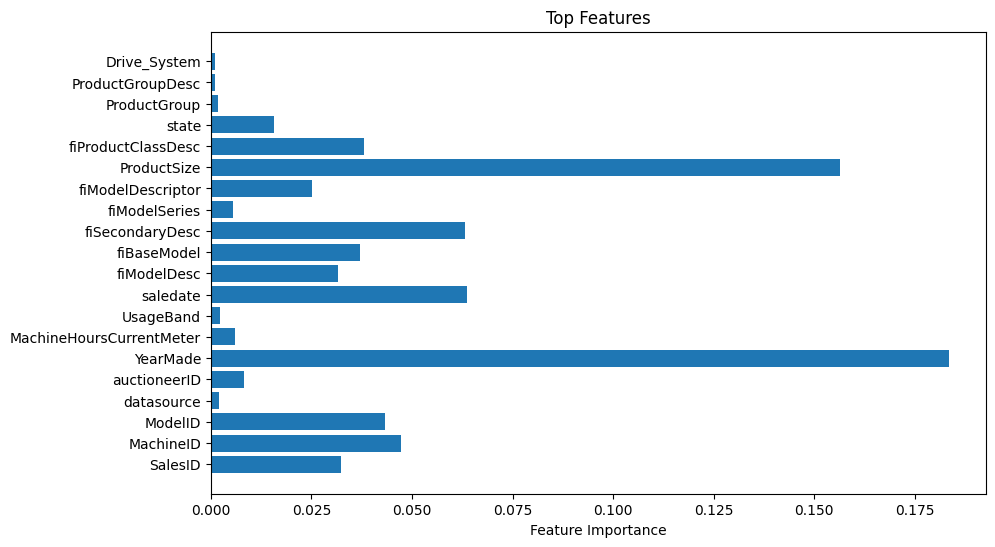

In [58]:
plot_feature(x_train.columns,model.feature_importances_)